In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostRegressor, Pool
import lightgbm as lgb

from sklearn.model_selection import cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor
import os, warnings
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("../data/get_around_pricing_project.csv")
df.head()

,Unnamed: 0,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


In [3]:
model_count = df['model_key'].value_counts()
df['model_key'] = df['model_key'].apply(lambda x: x if model_count[x] > 50 else "other")
fuel_count = df['fuel'].value_counts()
df['fuel'] = df['fuel'].apply(lambda x: x if fuel_count[x] > 50 else "other")
car_type_count = df['car_type'].value_counts()
df['car_type'] = df['car_type'].apply(lambda x: x if car_type_count[x] > 50 else "other")
df = df[df["mileage"] <= 500_000]
df = df.drop(columns=["Unnamed: 0", "winter_tires", "paint_color"])
df.head()

,model_key,mileage,engine_power,fuel,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,rental_price_per_day
0,Citroën,140411,100,diesel,other,True,True,False,False,True,True,106
1,Citroën,13929,317,petrol,other,True,True,False,False,False,True,264
2,Citroën,183297,120,diesel,other,False,False,False,False,True,False,101
3,Citroën,128035,135,diesel,other,True,True,False,False,True,True,158
4,Citroën,97097,160,diesel,other,True,True,False,False,False,True,183


In [4]:
boolean_columns = ["private_parking_available", "has_gps", "has_air_conditioning", "automatic_car", "has_getaround_connect", "has_speed_regulator"]

for column in boolean_columns:
    df[column] = df[column].map({True: 1, False: 0})

df.head()

,model_key,mileage,engine_power,fuel,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,rental_price_per_day
0,Citroën,140411,100,diesel,other,1,1,0,0,1,1,106
1,Citroën,13929,317,petrol,other,1,1,0,0,0,1,264
2,Citroën,183297,120,diesel,other,0,0,0,0,1,0,101
3,Citroën,128035,135,diesel,other,1,1,0,0,1,1,158
4,Citroën,97097,160,diesel,other,1,1,0,0,0,1,183


In [5]:
feature_target = "rental_price_per_day"
X = df.loc[:, df.columns != feature_target]
y = df[feature_target]

X.head()

,model_key,mileage,engine_power,fuel,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator
0,Citroën,140411,100,diesel,other,1,1,0,0,1,1
1,Citroën,13929,317,petrol,other,1,1,0,0,0,1
2,Citroën,183297,120,diesel,other,0,0,0,0,1,0
3,Citroën,128035,135,diesel,other,1,1,0,0,1,1
4,Citroën,97097,160,diesel,other,1,1,0,0,0,1


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
numeric_features = ["mileage", "engine_power", *boolean_columns]
categorical_features = ["model_key", "fuel", "car_type"]

In [17]:
numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler()) # TESTER VS ROBUST SCALER EN GRID SEARCH VOIR CE QUI IMPACT LE MIEUX
    ])

categorical_transformer = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist', min_frequency=30))
    ])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [9]:
models = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(loss_function="RMSE", depth=8, learning_rate=0.05,
                                    n_estimators=1000, random_state=42, verbose=0),
    "XGBoost": XGBRegressor(n_estimators=1000, learning_rate=0.05, subsample=0.8,
                                colsample_bytree=0.8, max_depth=8, random_state=42,
                                tree_method="hist", eval_metric="rmse"),
    "LightGBM": lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05,
                                    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                                    random_state=42),
}

results = []
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                        ('regressor', model)])
    rmse_scores = cross_val_score(pipe, X, y, cv=cv, scoring="neg_root_mean_squared_error")
    mae_scores = cross_val_score(pipe, X, y, cv=cv, scoring="neg_mean_absolute_error")
    r2_scores = cross_val_score(pipe, X, y, cv=cv, scoring="r2")

    results.append({"Model": name,
                    "Mean RMSE": (-rmse_scores).mean(),
                    "Std RMSE": (-rmse_scores).std(),
                    "MAE:": (-mae_scores).mean(),
                    "R²:": r2_scores.mean()})
df_result = pd.DataFrame(results)
df_result

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000250 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 352
[LightGBM] [Info] Number of data points in the train set: 3873, number of used features: 25
[LightGBM] [Info] Start training from score 121.434805
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 350
[LightGBM] [Info] Number of data points in the train set: 3873, number of used features: 25
[LightGBM] [Info] Start training from score 121.034082
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

,Model,Mean RMSE,Std RMSE,MAE:,R²:
0,RandomForest,16.809575,1.955589,10.776466,0.748207
1,CatBoost,15.671995,1.813403,10.106367,0.781275
2,XGBoost,16.778271,1.686385,10.746993,0.749360
3,LightGBM,16.283904,1.564976,10.870389,0.764141


In [10]:
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', CatBoostRegressor(loss_function="RMSE", depth=8, learning_rate=0.05,
                                    n_estimators=1000, random_state=42, verbose=0))
])

# Entraînement
pipe.fit(X_train, y_train)

# Prédictions
y_pred = pipe.predict(X_test)

Text(0.5, 1.0, 'Comparaison valeurs réelles vs prédites')

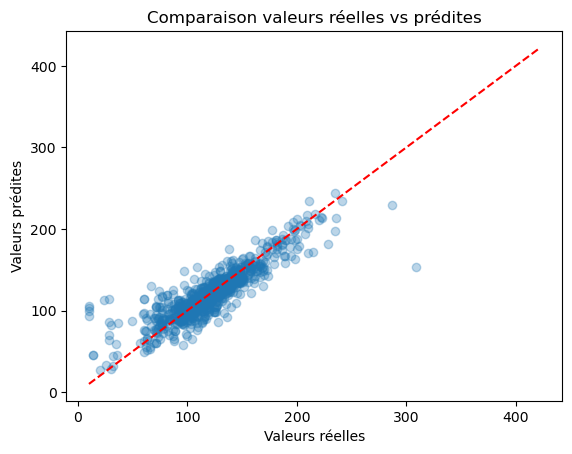

In [11]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Comparaison valeurs réelles vs prédites")


Text(0.5, 1.0, 'Analyse des résidus')

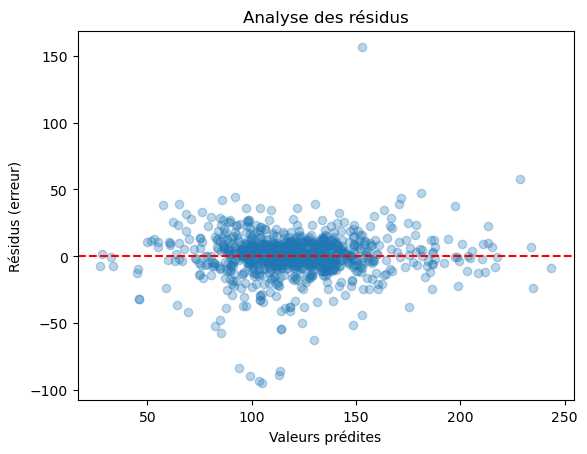

In [12]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus (erreur)")
plt.title("Analyse des résidus")


Text(0.5, 1.0, 'Distribution des erreurs')

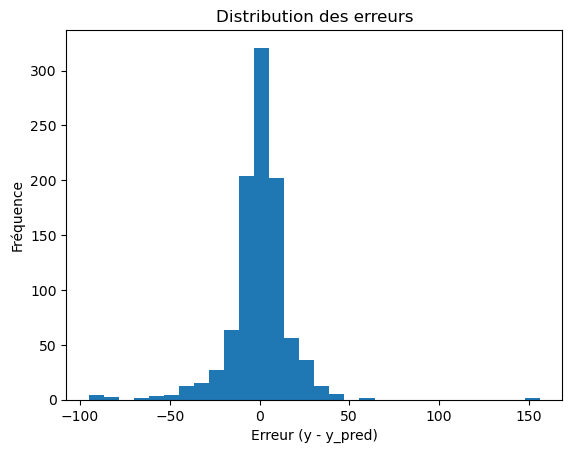

In [13]:
plt.hist(residuals, bins=30)
plt.xlabel("Erreur (y - y_pred)")
plt.ylabel("Fréquence")
plt.title("Distribution des erreurs")


Text(0.5, 1.0, 'Courbe d’apprentissage')

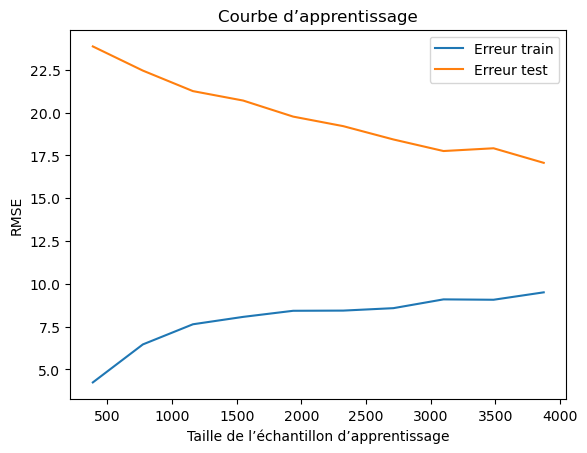

In [14]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    pipe, X, y, cv=5, scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

plt.plot(train_sizes, -train_scores.mean(axis=1), label="Erreur train")
plt.plot(train_sizes, -test_scores.mean(axis=1), label="Erreur test")
plt.xlabel("Taille de l’échantillon d’apprentissage")
plt.ylabel("RMSE")
plt.legend()
plt.title("Courbe d’apprentissage")


In [22]:
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning"
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', CatBoostRegressor(loss_function="RMSE", random_state=42, verbose=0))
])

# grille d’hyperparamètres
param_grid = {
    'regressor__depth': [6, 8, 10],              # profondeur max des arbres
    'regressor__learning_rate': [0.01, 0.05, 0.1], # taux d’apprentissage
    'regressor__n_estimators': [500, 1000, 2000],  # nombre d’arbres
    'regressor__l2_leaf_reg': [1, 3, 5, 10]        # régularisation L2
}

# GridSearchCV
grid = GridSearchCV(pipe, param_grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=2)
grid.fit(X, y)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score (RMSE) :", -grid.best_score_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


[CV] END regressor__depth=6, regressor__l2_leaf_reg=1, regressor__learning_rate=0.01, regressor__n_estimators=500; total time=   1.2s
[CV] END regressor__depth=6, regressor__l2_leaf_reg=1, regressor__learning_rate=0.01, regressor__n_estimators=500; total time=   1.1s
[CV] END regressor__depth=6, regressor__l2_leaf_reg=1, regressor__learning_rate=0.01, regressor__n_estimators=500; total time=   1.1s
[CV] END regressor__depth=6, regressor__l2_leaf_reg=1, regressor__learning_rate=0.05, regressor__n_estimators=500; total time=   1.2s
[CV] END regressor__depth=6, regressor__l2_leaf_reg=1, regressor__learning_rate=0.05, regressor__n_estimators=500; total time=   1.2s
[CV] END regressor__depth=6, regressor__l2_leaf_reg=1, regressor__learning_rate=0.05, regressor__n_estimators=500; total time=   1.2s
[CV] END regressor__depth=6, regressor__l2_leaf_reg=1, regressor__learning_rate=0.01, regressor__n_estimators=1000; total time=   2.2s
[CV] END regressor__depth=6, regressor__l2_leaf_reg=1, regres

In [25]:
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', CatBoostRegressor(loss_function="RMSE", random_state=42, verbose=0))
])

# grille d’hyperparamètres
param_grid = {
    'regressor__depth': [5, 6],              # profondeur max des arbres
    'regressor__learning_rate': [0.07, 0.08, 0.09], # taux d’apprentissage
    'regressor__n_estimators': [600, 650, 700],  # nombre d’arbres
    'regressor__l2_leaf_reg': [9, 10, 11]        # régularisation L2
}

# GridSearchCV
grid = GridSearchCV(pipe, param_grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=2)
grid.fit(X, y)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score (RMSE) :", -grid.best_score_)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END regressor__depth=5, regressor__l2_leaf_reg=9, regressor__learning_rate=0.07, regressor__n_estimators=600; total time=   0.9s
[CV] END regressor__depth=5, regressor__l2_leaf_reg=9, regressor__learning_rate=0.07, regressor__n_estimators=600; total time=   0.9s
[CV] END regressor__depth=5, regressor__l2_leaf_reg=9, regressor__learning_rate=0.07, regressor__n_estimators=600; total time=   0.9s
[CV] END regressor__depth=5, regressor__l2_leaf_reg=9, regressor__learning_rate=0.08, regressor__n_estimators=600; total time=   0.9s
[CV] END regressor__depth=5, regressor__l2_leaf_reg=9, regressor__learning_rate=0.08, regressor__n_estimators=600; total time=   0.9s
[CV] END regressor__depth=5, regressor__l2_leaf_reg=9, regressor__learning_rate=0.08, regressor__n_estimators=600; total time=   0.9s
[CV] END regressor__depth=5, regressor__l2_leaf_reg=9, regressor__learning_rate=0.07, regressor__n_estimators=650; total time=   1.0s


In [26]:
best_params = grid.best_params_
print(best_params)

{'regressor__depth': 6, 'regressor__l2_leaf_reg': 9, 'regressor__learning_rate': 0.08, 'regressor__n_estimators': 700}


In [27]:
clean_params = {k.split('__')[-1]: v for k, v in best_params.items()}
print(clean_params)

{'depth': 6, 'l2_leaf_reg': 9, 'learning_rate': 0.08, 'n_estimators': 700}


In [39]:
final_model = CatBoostRegressor(**clean_params, random_state=42)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', final_model)
])
final_pipeline.fit(X_train, y_train)

0:	learn: 32.0418421	total: 1.42ms	remaining: 993ms
1:	learn: 30.8319446	total: 3.12ms	remaining: 1.09s
2:	learn: 29.7065899	total: 4.42ms	remaining: 1.03s
3:	learn: 28.6809529	total: 5.72ms	remaining: 996ms
4:	learn: 27.6907059	total: 7.04ms	remaining: 979ms
5:	learn: 26.8886578	total: 8.19ms	remaining: 948ms
6:	learn: 26.1196096	total: 9.32ms	remaining: 922ms
7:	learn: 25.4131317	total: 10.4ms	remaining: 903ms
8:	learn: 24.7805911	total: 11.6ms	remaining: 887ms
9:	learn: 24.1535702	total: 12.6ms	remaining: 871ms
10:	learn: 23.5993889	total: 13.7ms	remaining: 861ms
11:	learn: 23.0785544	total: 14.8ms	remaining: 851ms
12:	learn: 22.5950088	total: 16ms	remaining: 843ms
13:	learn: 22.1544216	total: 17.2ms	remaining: 843ms
14:	learn: 21.7771653	total: 18.4ms	remaining: 839ms
15:	learn: 21.4505193	total: 19.5ms	remaining: 835ms
16:	learn: 21.1241628	total: 20.7ms	remaining: 830ms
17:	learn: 20.8309849	total: 21.8ms	remaining: 827ms
18:	learn: 20.5539591	total: 22.9ms	remaining: 822ms
19:	l

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['mileage', 'engine_power',
                                                   'private_parking_available',
                                                   'has_gps',
                                                   'has_air_conditioning',
                                                   'automatic_car',
                                                   'has_getaround_connect',
                                                   'has_speed_regulator']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='infrequent_if_exist',
                                                                                 min_frequency=30))]),
                                                  ['model_key', 'fuel',
                                                   'car_type'])])),
                ('regressor',
                 <catboost.core.CatBoostRegressor object at 0x182c0b320>)])

In [40]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
y_pred = final_pipeline.predict(X_test)

print("RMSE :", root_mean_squared_error(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("R² :", r2_score(y_test, y_pred))

RMSE : 16.105325013160147
MAE : 10.48659137615165
R² : 0.7743958502216666


In [41]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test, y_pred)
print("MAPE :", mape)


MAPE : 0.1473220314889151


In [42]:
model = final_pipeline.named_steps['regressor']
importances = model.feature_importances_

feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df

,feature,importance
1,num__engine_power,34.420784
0,num__mileage,26.597023
3,num__has_gps,8.573549
25,cat__car_type_suv,4.836685
6,num__has_getaround_connect,4.573793
8,cat__model_key_BMW,2.665135
20,cat__car_type_estate,2.640400
18,cat__fuel_petrol,2.148184
5,num__automatic_car,2.017403
9,cat__model_key_Citroën,1.768772


<Figure size 1000x600 with 0 Axes>

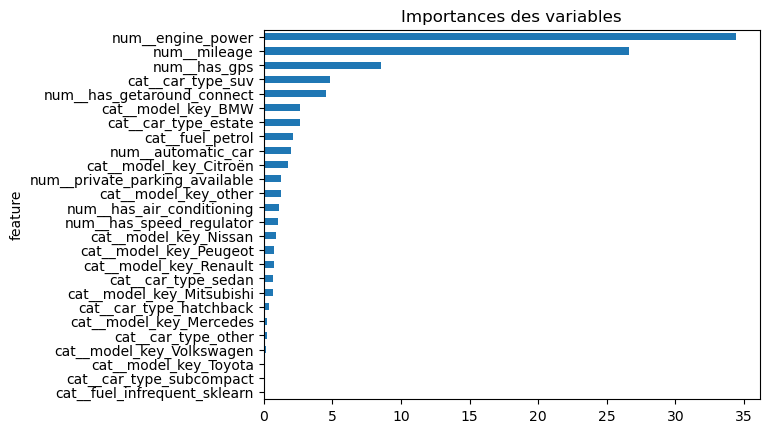

In [43]:

plt.figure(figsize=(10,6))
feature_importance_df.sort_values(by="importance", ascending=True).plot.barh(x="feature", y="importance", legend=False)
plt.title("Importances des variables")
plt.show()